In [137]:
import numpy as np
import pandas as pd

In [138]:
df=pd.read_csv('spam.csv',encoding ="latin1")


In [139]:
df.head(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


## 1. Data Cleaning

In [141]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [142]:
df.sample(5)

,v1,v2
3721,ham,I'm in a movie... Collect car oredi...
1698,spam,"Free msg. Sorry, a service you ordered from 81..."
935,ham,Then dun wear jeans lor...
4543,ham,when you and derek done with class?
605,ham,TaKe CaRE n gET WeLL sOOn


In [143]:
df.rename(columns={'v1':'target','v2':'text'},inplace=True)

In [144]:
df.head(5)

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [145]:
from sklearn.preprocessing import LabelEncoder      #converts spam(unwanted) as 1 amd ham(legitimate) as 0
encoder= LabelEncoder()
df['target'] = encoder.fit_transform(df['target'])

In [146]:
print(df.iloc[4])

target                                                    0
text      Nah I don't think he goes to usf, he lives aro...
Name: 4, dtype: object


In [147]:
#checking missing value
df.isnull().sum()

target    0
text      0
dtype: int64

In [148]:
#checking duplicate value
df.duplicated().sum()

403

In [149]:
#remove duplicates
df =df.drop_duplicates(keep='first')   #keeping the first occurence of duplicates

In [150]:
df.duplicated().sum()

0

In [151]:
df.shape

(5169, 2)

## 2.EDA

In [153]:
#checking no of spams and hams 
df['target'].value_counts()     

target
0    4516
1     653
Name: count, dtype: int64

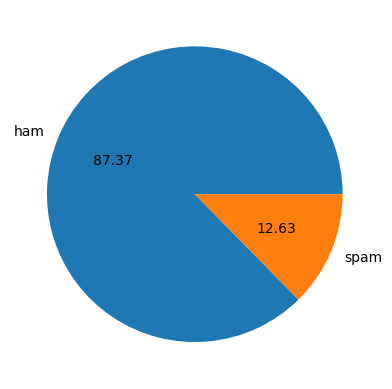

In [154]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(),labels=['ham','spam'],autopct="%0.2f")
plt.show()

In [155]:
#DATA IS IMBLANCED

In [156]:
import nltk                   #nltk:natural language toolkit
nltk.download('punkt')        # punkt:model trained to detect sentence boundries
nltk.download('punkt_tab')
nltk.download('stopwords')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\mehaq\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\mehaq\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\mehaq\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [157]:
#number of characters in each text
df['num_characters']=df['text'].apply(len)

In [158]:
df.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [159]:
#number of words in each text 
df['num_words'] = df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [160]:
df.head()

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [161]:
#number of sentences in each text
df['num_sentences']= df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [162]:
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [163]:
#describe ham
df[df['target']==0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [164]:
#describe spam
df[df['target']==1][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


<Axes: xlabel='num_characters', ylabel='Count'>

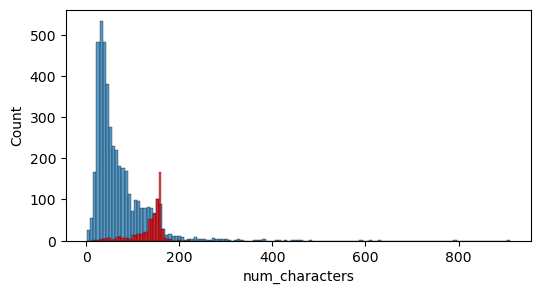

In [165]:
import seaborn as sns
plt.figure(figsize=(6,3))
sns.histplot(df[df['target'] == 0]['num_characters'])
sns.histplot(df[df['target'] == 1]['num_characters'], color='red')


In [166]:
# By seeing mean and from histplot ,spam has more characters,words and sentence than ham

<Figure size 600x300 with 0 Axes>

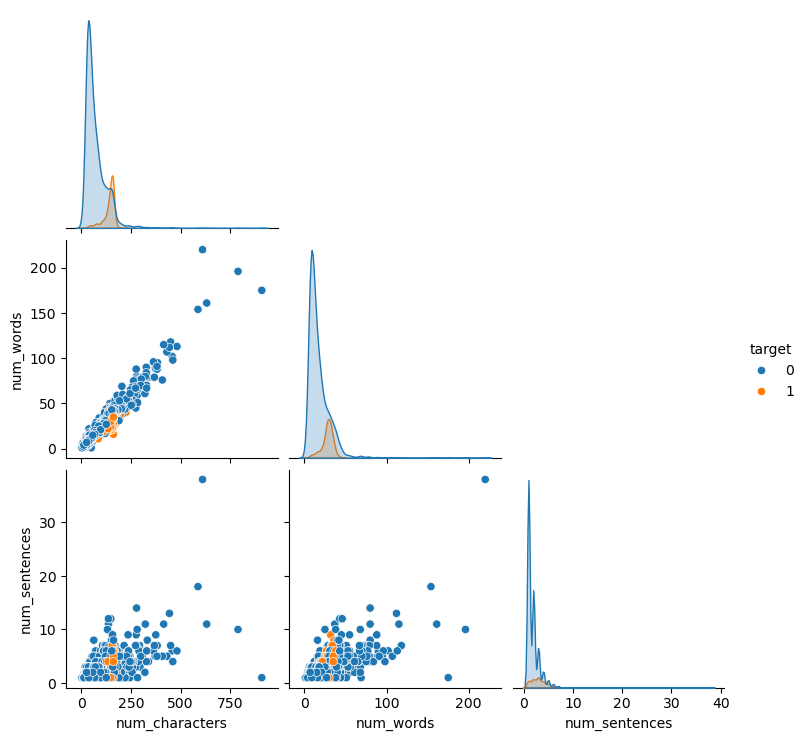

<Figure size 600x300 with 0 Axes>

In [167]:
sns.pairplot(df,hue='target',corner=True)
plt.figure(figsize=(6,3))

In [168]:
#from pairplot,there are outliers present in data

<Axes: >

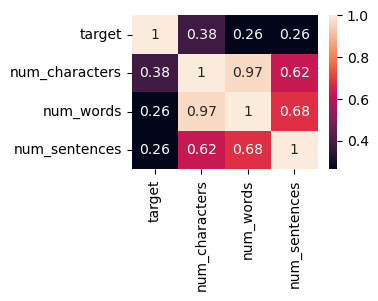

In [169]:
numeric_df=df[['target','num_characters','num_words','num_sentences']]
plt.figure(figsize=(3,2))
sns.heatmap(numeric_df.corr(),annot=True)


In [170]:
#from correaltion map,characters,words,sentences are highly correlated(.97,etc) so we will choose one among them.
#Also chareacters is highly correlated with target in comaprison to word and sentences.
#so num_character will be choosed for creating model


## 3.Data Preprocessing

In [172]:
'''lowercase
tokenisation
removing special characters
removing stopwords and punctuation
stemming
'''

'lowercase\ntokenisation\nremoving special characters\nremoving stopwords and punctuation\nstemming\n'

In [173]:
df.head(5)

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [174]:
import nltk
import string
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

ps = PorterStemmer()

def transform_text(text):
    text = text.lower()
    words = nltk.word_tokenize(text)

    cleaned_words = []
    
    for word in words:
        if word.isalnum() and word not in stopwords.words('english'):
            cleaned_words.append(ps.stem(word))

    return " ".join(cleaned_words)

In [175]:
df['transformed_text']= df['text'].apply(transform_text)

In [176]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [177]:
!pip install wordcloud

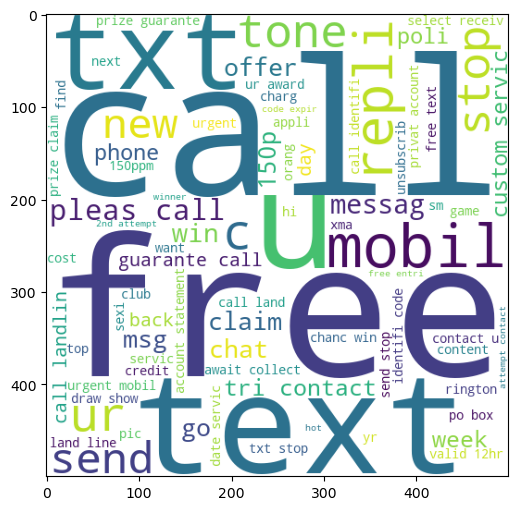

In [178]:
# to show thw the top words used
from wordcloud import WordCloud
wc= WordCloud(width=500,height=500,min_font_size=10,background_color='white')
spam_wc = wc.generate(df[df['target']==1]['transformed_text'].str.cat(sep=" "))
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

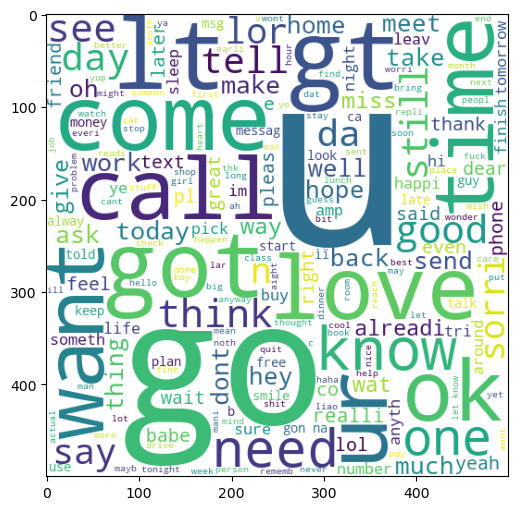

In [179]:
wc= WordCloud(width=500,height=500,min_font_size=10,background_color='white')
spam_wc = wc.generate(df[df['target']==0]['transformed_text'].str.cat(sep=" "))
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

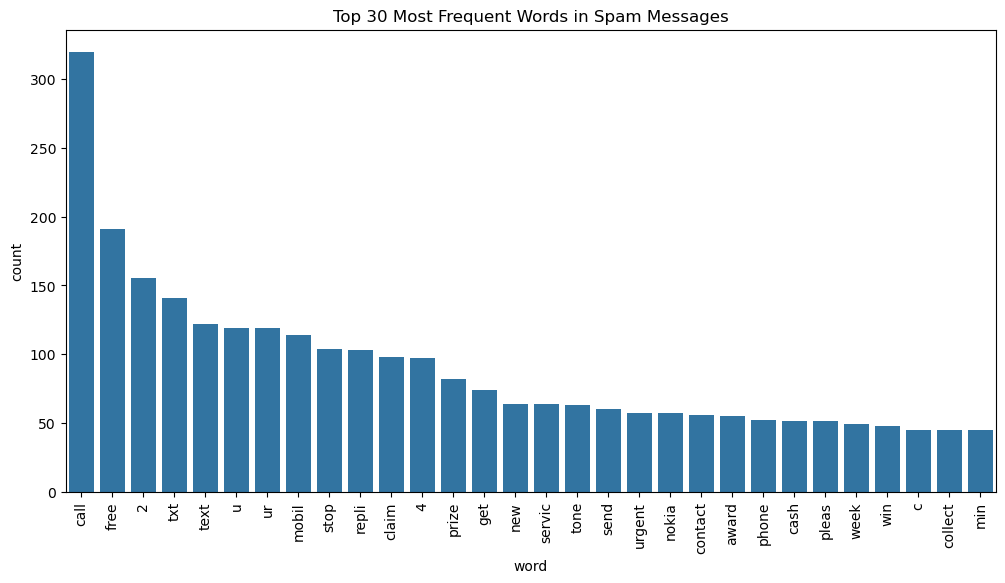

In [180]:
from collections import Counter

# Create list of spam words
spam_corpus = []
for msg in df[df['target'] == 1]['transformed_text'].tolist():
    spam_corpus.extend(msg.split())

# Get top 30 most common words
top_words = pd.DataFrame(Counter(spam_corpus).most_common(30), columns=['word','count'])

# Plot
plt.figure(figsize=(12,6))
sns.barplot(x='word', y='count', data=top_words)
plt.xticks(rotation='vertical')
plt.title("Top 30 Most Frequent Words in Spam Messages")
plt.show()

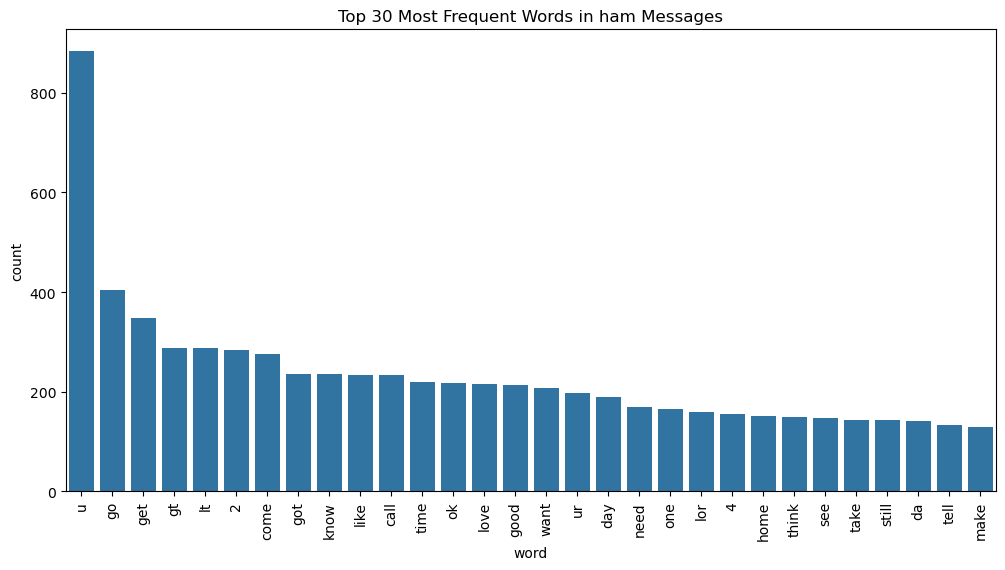

In [181]:
# Create list of ham words
ham_corpus = []
for msg in df[df['target'] == 0]['transformed_text'].tolist():
    ham_corpus.extend(msg.split())

# Get top 30 most common words
top_words = pd.DataFrame(Counter(ham_corpus).most_common(30), columns=['word','count'])

# Plot
plt.figure(figsize=(12,6))
sns.barplot(x='word', y='count', data=top_words)
plt.xticks(rotation='vertical')
plt.title("Top 30 Most Frequent Words in ham Messages")
plt.show()

In [182]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


## MODEL BUILDING 

'''naive bayes works best on textual data'''

### vectorize text using bag of word

In [185]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer()


In [186]:
x =cv.fit_transform(df['transformed_text']).toarray()
# from sparse matrix to dense matrix

In [187]:
x.shape   
#6708 words are in 5169 text messages

(5169, 6708)

In [188]:
x

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int64)

In [189]:
y = df['target'].values

In [190]:
y.shape

(5169,)

In [191]:
y

array([0, 0, 1, ..., 0, 0, 0])

In [192]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=48)


In [193]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score


In [194]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()


In [195]:
gnb.fit(x_train,y_train)
y_pred1 = gnb.predict(x_test)

print('Accuracy',accuracy_score(y_test,y_pred1))
print('Confusion_Matrix',confusion_matrix(y_test,y_pred1))
print('Precision',precision_score(y_test,y_pred1))

Accuracy 0.8626692456479691
Confusion_Matrix [[784 118]
 [ 24 108]]
Precision 0.4778761061946903


In [196]:
mnb.fit(x_train,y_train)
y_pred2 = mnb.predict(x_test)

print('Accuracy',accuracy_score(y_test,y_pred2))
print('Confusion_Matrix',confusion_matrix(y_test,y_pred2))
print('Precision',precision_score(y_test,y_pred2))

Accuracy 0.9671179883945842
Confusion_Matrix [[878  24]
 [ 10 122]]
Precision 0.8356164383561644


In [197]:
bnb.fit(x_train,y_train)
y_pred3 = bnb.predict(x_test)

print('Accuracy',accuracy_score(y_test,y_pred3))
print('Confusion_Matrix',confusion_matrix(y_test,y_pred3))
print('Precision',precision_score(y_test,y_pred3))

Accuracy 0.9632495164410058
Confusion_Matrix [[897   5]
 [ 33  99]]
Precision 0.9519230769230769


In [198]:
# BINOMIAL NAIVE BAYES GOT MOST PRECISION-95%

### vectorize text using tfidf (term frequency- inverse document frequency)

In [199]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer()  # can add max_features = 3000 in tfidf

In [200]:
x =tfidf.fit_transform(df['transformed_text']).toarray()

In [201]:
y = df['target'].values

In [202]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=48)

gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [203]:
gnb.fit(x_train,y_train)
y_pred1 = gnb.predict(x_test)

print('Accuracy',accuracy_score(y_test,y_pred1))
print('Confusion_Matrix',confusion_matrix(y_test,y_pred1))
print('Precision',precision_score(y_test,y_pred1))

Accuracy 0.8597678916827853
Confusion_Matrix [[785 117]
 [ 28 104]]
Precision 0.47058823529411764


In [204]:
mnb.fit(x_train,y_train)
y_pred2 = mnb.predict(x_test)

print('Accuracy',accuracy_score(y_test,y_pred2))
print('Confusion_Matrix',confusion_matrix(y_test,y_pred2))
print('Precision',precision_score(y_test,y_pred2))

Accuracy 0.9526112185686654
Confusion_Matrix [[902   0]
 [ 49  83]]
Precision 1.0


In [205]:
bnb.fit(x_train,y_train)
y_pred3 = bnb.predict(x_test)

print('Accuracy',accuracy_score(y_test,y_pred3))
print('Confusion_Matrix',confusion_matrix(y_test,y_pred3))
print('Precision',precision_score(y_test,y_pred3))

Accuracy 0.9632495164410058
Confusion_Matrix [[897   5]
 [ 33  99]]
Precision 0.9519230769230769


In [206]:
# MULTINOMIAL NAIVE BAYES GOT BEST PRECISION -100%  
#so instead of bag of words ,tdidf will be used for word vectorization
#(as data is imbalanced ,so accuracy doest matter that much ,but precision 
#matters )
# and mnb is used

#### '''tfidf vectorizer + mnb got best precision +accuracy'''

### Implementing other models
'''trying to increase accuracy as well'''

In [208]:
!pip install xgboost

In [209]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [210]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [211]:
clfs = {
    'SVC' : svc,
    'KN' : knc, 
    'NB': mnb, 
    'DT': dtc, 
    'LR': lrc, 
    'RF': rfc, 
    'AdaBoost': abc, 
    'BgC': bc, 
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [212]:
def train_classifier(clf,x_train,y_train,x_test,y_test):
    clf.fit(x_train,y_train)
    y_pred = clf.predict(x_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    
    return accuracy,precision

In [213]:
train_classifier(svc,x_train,y_train,x_test,y_test)

(0.965183752417795, 0.9615384615384616)

In [214]:
accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():
    
    current_accuracy,current_precision = train_classifier(clf, x_train,y_train,x_test,y_test)
    
    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)

performance_df

For  SVC
Accuracy -  0.965183752417795
Precision -  0.9615384615384616
For  KN
Accuracy -  0.9003868471953579
Precision -  1.0
For  NB
Accuracy -  0.9526112185686654
Precision -  1.0
For  DT
Accuracy -  0.9294003868471954
Precision -  0.8041237113402062
For  LR
Accuracy -  0.9429400386847195
Precision -  0.9101123595505618
For  RF
Accuracy -  0.9632495164410058
Precision -  0.9895833333333334


C:\Users\mehaq\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


For  AdaBoost
Accuracy -  0.960348162475822
Precision -  0.9252336448598131
For  BgC
Accuracy -  0.9535783365570599
Precision -  0.85
For  ETC
Accuracy -  0.9680851063829787
Precision -  0.9805825242718447
For  GBDT
Accuracy -  0.9400386847195358
Precision -  0.9069767441860465
For  xgb
Accuracy -  0.9632495164410058
Precision -  0.9051724137931034


,Algorithm,Accuracy,Precision
1,KN,0.900387,1.000000
2,NB,0.952611,1.000000
5,RF,0.963250,0.989583
8,ETC,0.968085,0.980583
0,SVC,0.965184,0.961538
6,AdaBoost,0.960348,0.925234
4,LR,0.942940,0.910112
9,GBDT,0.940039,0.906977
10,xgb,0.963250,0.905172
7,BgC,0.953578,0.850000


In [215]:
# NB,ETC,RF,SVC ARE BEST MODELS and AMong them naive bayes(mnb) got best precision ,so we will consider that

## model improve
''' 1. Change the max_features parameter of TfIdf'''

def create_metric_df(suffix):
    return pd.DataFrame({
        'Algorithm': clfs.keys(),
        f'Accuracy_{suffix}': accuracy_scores,
        f'Precision_{suffix}': precision_scores
    })

temp_max = create_metric_df('max_ft_3000')

final_df = performance_df.merge(temp_max, on='Algorithm')

final_df                    

In [303]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))